In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



# Plot style
sns.set_style("whitegrid")


**1. Collect and load the CSV dataset**

In [ ]:
df = pd.read_csv("SUPER MARKET DATA.csv")

df.head()


,Invoice ID,Date,Branch,City,Customer Type,Gender,Product,Category,Quantity,Unit Price,Payment,Rating,Sales
0,INV0001,2026-06-01,A,Jaipur,Member,Male,Milk,Dairy,4,57.13,UPI,3.8,228.52
1,INV0002,2026-02-26,A,Jaipur,Normal,Male,Rice,Grocery,9,66.85,Net Banking,3.9,601.65
2,INV0003,2026-02-09,C,Mumbai,Normal,Female,Milk,Dairy,3,57.28,Card,3.4,171.84
3,INV0004,2026-01-12,C,Mumbai,Member,Female,Shampoo,Personal Care,2,168.27,Card,4.5,336.54
4,INV0005,2026-06-30,A,Jaipur,Normal,Female,Apples,Fruits,5,130.57,Cash,3.1,652.85


In [ ]:

df.shape

(500, 13)

In [ ]:

df.columns

Index(['Invoice ID', 'Date', 'Branch', 'City', 'Customer Type', 'Gender',
       'Product', 'Category', 'Quantity', 'Unit Price', 'Payment', 'Rating',
       'Sales'],
      dtype='object')

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Invoice ID     500 non-null    object 
 1   Date           500 non-null    object 
 2   Branch         500 non-null    object 
 3   City           500 non-null    object 
 4   Customer Type  500 non-null    object 
 5   Gender         500 non-null    object 
 6   Product        500 non-null    object 
 7   Category       500 non-null    object 
 8   Quantity       500 non-null    int64  
 9   Unit Price     500 non-null    float64
 10  Payment        500 non-null    object 
 11  Rating         500 non-null    float64
 12  Sales          500 non-null    float64
dtypes: float64(3), int64(1), object(9)
memory usage: 50.9+ KB


In [ ]:
df.describe()


,Quantity,Unit Price,Rating,Sales
count,500.000000,500.000000,500.000000,500.000000
mean,5.536000,88.660700,3.994400,488.822160
std,2.875629,57.284029,0.574481,437.327833
min,1.000000,27.670000,3.000000,28.610000
25%,3.000000,43.955000,3.500000,189.212500
50%,5.500000,61.880000,4.000000,335.910000
75%,8.000000,128.567500,4.500000,609.885000
max,10.000000,236.710000,5.000000,2114.820000


In [50]:
df.dtypes

,0
Invoice ID,object
Date,object
Branch,object
City,object
Customer Type,object
Gender,object
Product,object
Category,object
Quantity,int64
Unit Price,float64


**2. Check for missing or incorrect values**

In [ ]:

df.isnull().sum()

,0
Invoice ID,0
Date,0
Branch,0
City,0
Customer Type,0
Gender,0
Product,0
Category,0
Quantity,0
Unit Price,0


In [ ]:

df.duplicated().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()


**3. Calculate Sales = Quantity × Unit Price**

In [ ]:
df['Sales'] = df['Quantity'] * df['Unit Price']


In [ ]:
df[['Quantity', 'Unit Price', 'Sales']].head()


,Quantity,Unit Price,Sales
0,4,57.13,228.52
1,9,66.85,601.65
2,3,57.28,171.84
3,2,168.27,336.54
4,5,130.57,652.85


In [51]:
total_sales = df['Sales'].sum()

print(f"Total Sales: ₹{total_sales:,.2f}")


Total Sales: ₹244,411.08


In [52]:
total_quantity = df['Quantity'].sum()

print("Total Quantity Sold:", total_quantity)


Total Quantity Sold: 2768


**4. Group and summarize the data using totals, counts, and averages**

In [ ]:

total_sales = df['Sales'].sum()


total_quantity = df['Quantity'].sum()


total_transactions = df['Invoice ID'].count()


average_sales = df['Sales'].mean()


average_rating = df['Rating'].mean()

print(f"Total Sales: ₹{total_sales:,.2f}")
print(f"Total Quantity Sold: {total_quantity}")
print(f"Total Transactions: {total_transactions}")
print(f"Average Sales per Transaction: ₹{average_sales:,.2f}")
print(f"Average Customer Rating: {average_rating:.2f}")


Total Sales: ₹244,411.08
Total Quantity Sold: 2768
Total Transactions: 500
Average Sales per Transaction: ₹488.82
Average Customer Rating: 3.99


Sales by Product

In [ ]:
product_summary = df.groupby('Product').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Number_of_Transactions=('Invoice ID', 'count'),
    Average_Rating=('Rating', 'mean')
).sort_values('Total_Sales', ascending=False)

product_summary


,Total_Sales,Total_Quantity,Number_of_Transactions,Average_Rating
Product,,,,
Cheese,27906.30,126,26,3.976923
Coffee,27694.87,153,24,3.858333
Shampoo,27497.48,152,27,3.918519
Cooking Oil,21525.06,142,26,3.965385
Tea,17681.59,146,29,4.020690
Apples,17057.41,119,20,3.860000
Face Wash,11946.85,100,19,3.900000
Rice,11754.17,167,29,3.844828
Cold Drink,10731.78,166,29,3.979310


Sales by Branch

In [ ]:
branch_summary = df.groupby(['Branch', 'City']).agg(
    Total_Sales=('Sales', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Number_of_Transactions=('Invoice ID', 'count'),
    Average_Rating=('Rating', 'mean')
).sort_values('Total_Sales', ascending=False)

branch_summary


,,Total_Sales,Total_Quantity,Number_of_Transactions,Average_Rating
Branch,City,,,,
C,Mumbai,72469.45,807,143,4.046154
B,Delhi,64116.26,692,133,3.975188
D,Bengaluru,55468.29,669,119,4.092437
A,Jaipur,52357.08,600,105,3.837143


Sales by Category

In [ ]:
category_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Quantity=('Quantity', 'sum'),
    Number_of_Transactions=('Invoice ID', 'count'),
    Average_Rating=('Rating', 'mean')
).sort_values('Total_Sales', ascending=False)

category_summary


,Total_Sales,Total_Quantity,Number_of_Transactions,Average_Rating
Category,,,,
Beverages,56108.24,465,82,3.958537
Personal Care,45943.96,399,73,3.953425
Dairy,43992.00,345,68,4.030882
Grocery,40470.47,439,82,3.941463
Fruits,23263.17,223,44,3.829545
Snacks,16992.97,443,75,4.108000
Vegetables,11124.17,290,48,3.985417
Bakery,6516.10,164,28,4.242857


Customer Type Summary

In [ ]:
customer_summary = df.groupby('Customer Type').agg(
    Total_Sales=('Sales', 'sum'),
    Average_Sales=('Sales', 'mean'),
    Total_Quantity=('Quantity', 'sum'),
    Number_of_Transactions=('Invoice ID', 'count'),
    Average_Rating=('Rating', 'mean')
)

customer_summary


,Total_Sales,Average_Sales,Total_Quantity,Number_of_Transactions,Average_Rating
Customer Type,,,,,
Member,143009.30,483.139527,1659,296,4.013514
Normal,101401.78,497.067549,1109,204,3.966667


Payment Method Summary

In [ ]:
payment_summary = df.groupby('Payment').agg(
    Total_Sales=('Sales', 'sum'),
    Number_of_Transactions=('Invoice ID', 'count'),
    Average_Sales=('Sales', 'mean')
).sort_values('Number_of_Transactions', ascending=False)

payment_summary


,Total_Sales,Number_of_Transactions,Average_Sales
Payment,,,
UPI,67910.33,127,534.727008
Net Banking,65194.93,126,517.420079
Card,57265.64,125,458.125120
Cash,54040.18,122,442.952295


 Gender Summary

In [ ]:
gender_summary = df.groupby('Gender').agg(
    Total_Sales=('Sales', 'sum'),
    Average_Sales=('Sales', 'mean'),
    Total_Quantity=('Quantity', 'sum'),
    Number_of_Transactions=('Invoice ID', 'count'),
    Average_Rating=('Rating', 'mean')
)

gender_summary


,Total_Sales,Average_Sales,Total_Quantity,Number_of_Transactions,Average_Rating
Gender,,,,,
Female,123954.12,486.094588,1380,255,4.006667
Male,120456.96,491.661061,1388,245,3.981633


**5. Create charts to compare the results.**

Sales by Product

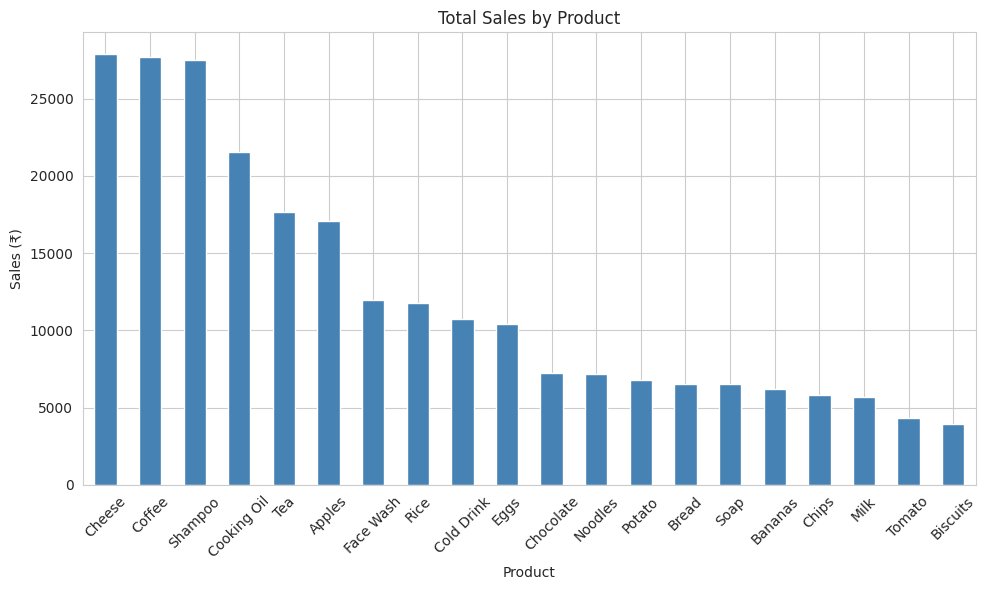

In [29]:
plt.figure(figsize=(10, 6))

product_sales = df.groupby('Product')['Sales'].sum().sort_values(ascending=False)

product_sales.plot(kind='bar', color='steelblue')

plt.title('Total Sales by Product')
plt.xlabel('Product')
plt.ylabel('Sales (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Sales by Branch

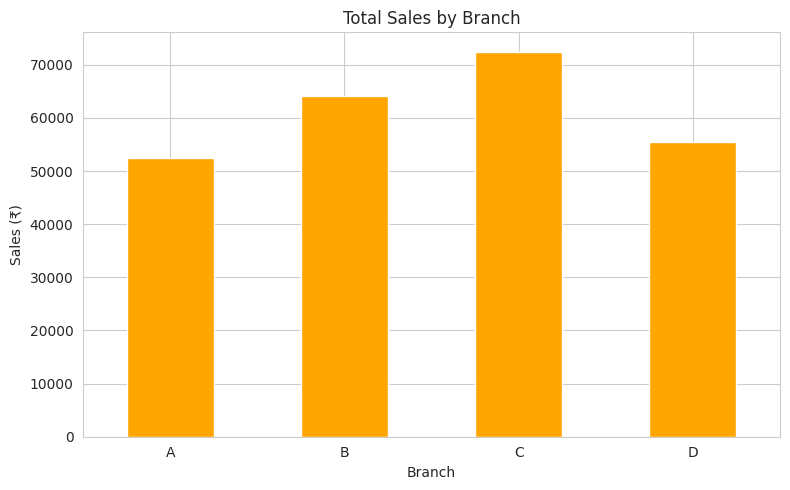

In [30]:
plt.figure(figsize=(8, 5))

branch_sales = df.groupby('Branch')['Sales'].sum()

branch_sales.plot(kind='bar', color='orange')

plt.title('Total Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Sales (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Sales by Category

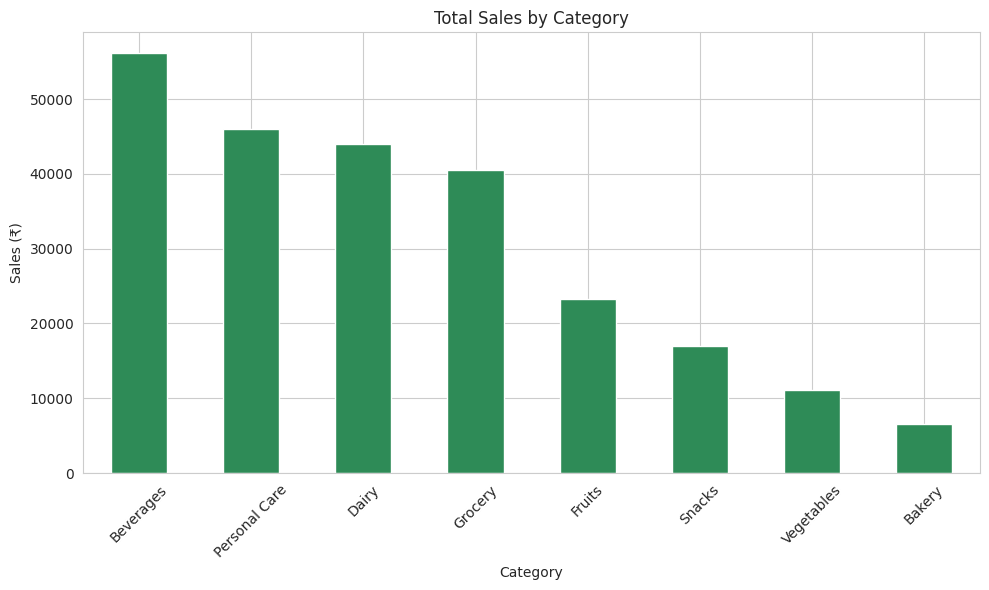

In [31]:
plt.figure(figsize=(10, 6))

category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales.plot(kind='bar', color='seagreen')

plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Sales (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Payment Method Comparison

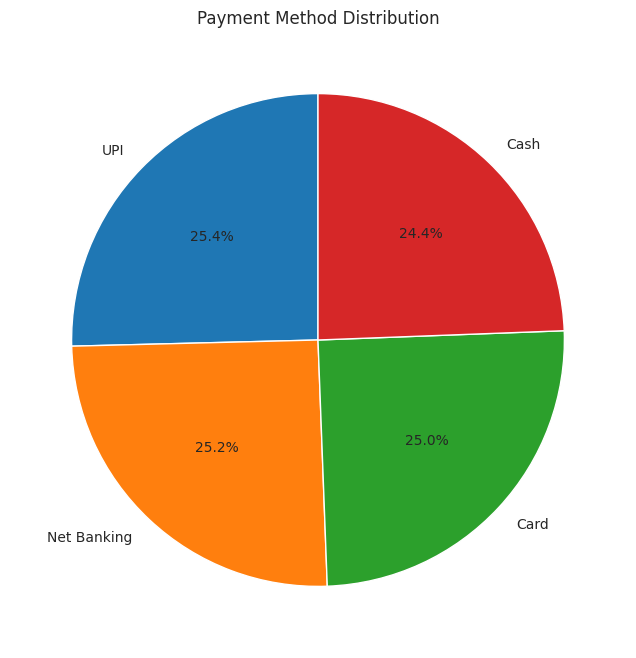

In [32]:
payment_counts = df['Payment'].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Payment Method Distribution')
plt.show()


 Member vs Normal Customers

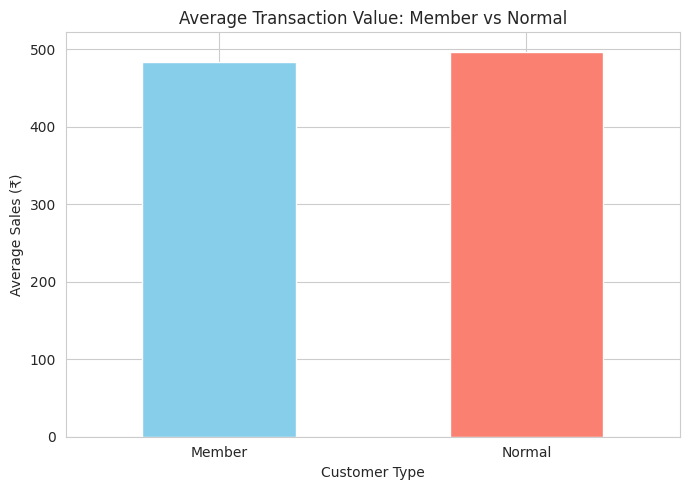

In [33]:
customer_sales = df.groupby('Customer Type')['Sales'].mean()

plt.figure(figsize=(7, 5))

customer_sales.plot(
    kind='bar',
    color=['skyblue', 'salmon']
)

plt.title('Average Transaction Value: Member vs Normal')
plt.xlabel('Customer Type')
plt.ylabel('Average Sales (₹)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Average Rating by Category

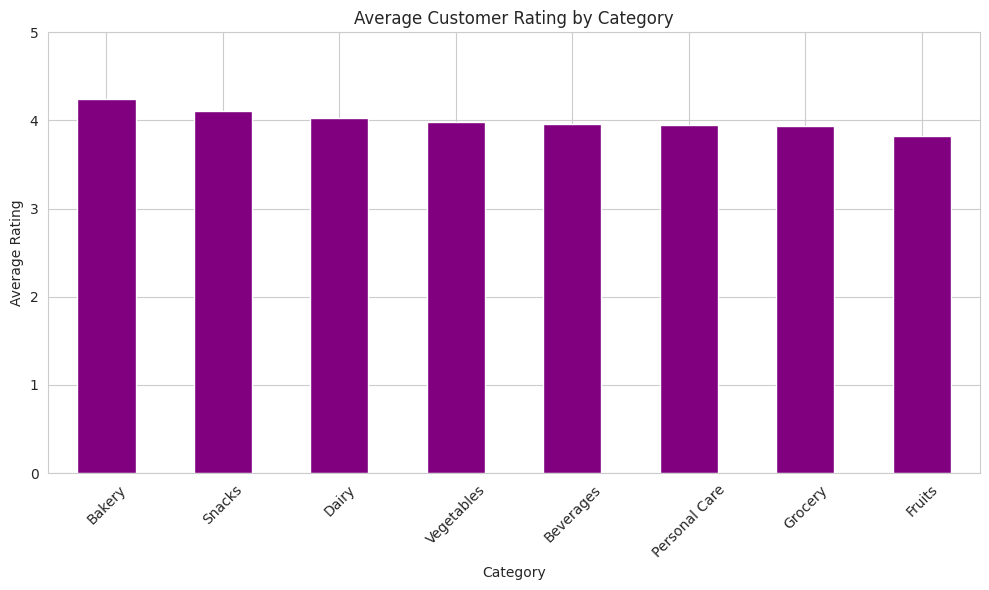

In [34]:
category_rating = df.groupby('Category')['Rating'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

category_rating.plot(
    kind='bar',
    color='purple'
)

plt.title('Average Customer Rating by Category')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.ylim(0, 5)
plt.tight_layout()
plt.show()


 Quantity Sold by Category

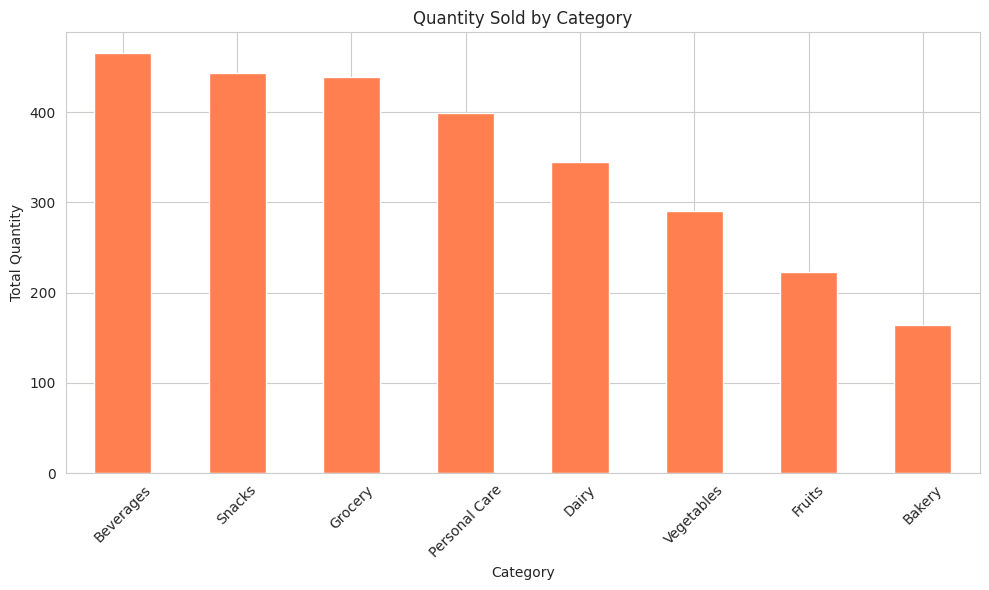

In [37]:
category_quantity = df.groupby('Category')['Quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))

category_quantity.plot(
    kind='bar',
    color='coral'
)

plt.title('Quantity Sold by Category')
plt.xlabel('Category')
plt.ylabel('Total Quantity')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


 Rating Distribution

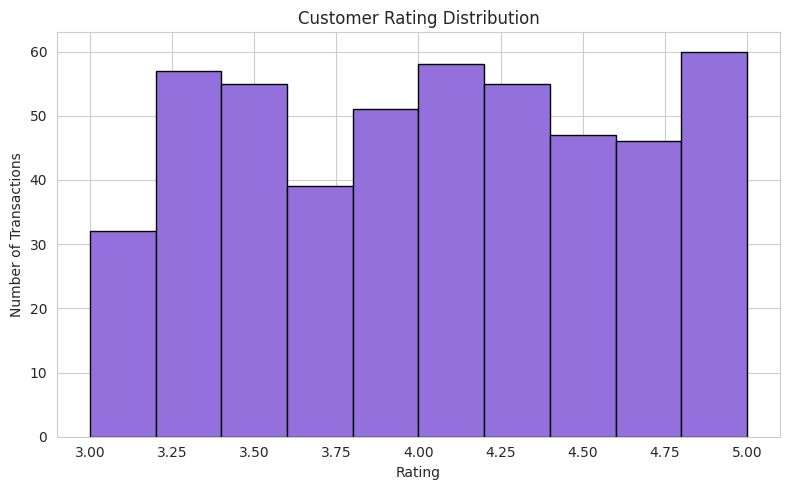

In [38]:
plt.figure(figsize=(8, 5))

plt.hist(
    df['Rating'],
    bins=10,
    color='mediumpurple',
    edgecolor='black'
)

plt.title('Customer Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()


Sales vs Quantity

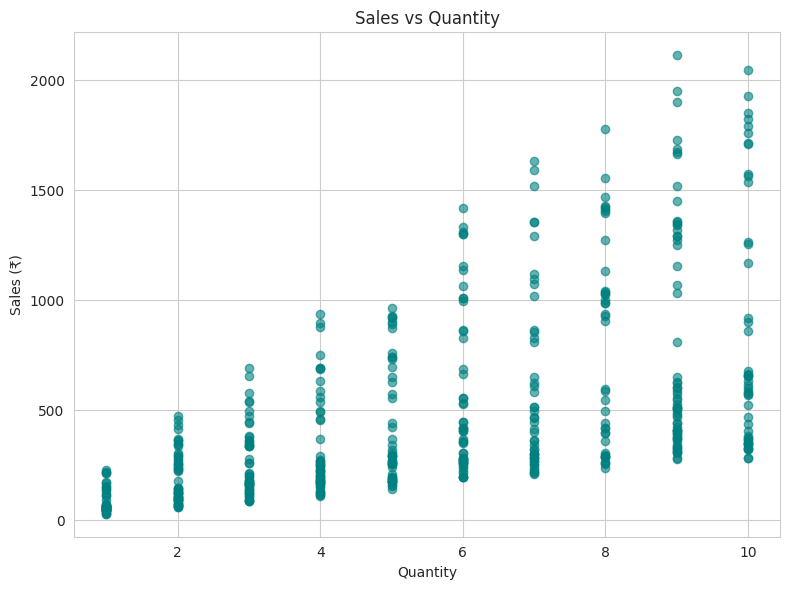

In [39]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df['Quantity'],
    df['Sales'],
    alpha=0.6,
    color='teal'
)

plt.title('Sales vs Quantity')
plt.xlabel('Quantity')
plt.ylabel('Sales (₹)')
plt.grid(True)
plt.tight_layout()
plt.show()


**6. Use the results to make business decisions**


In [42]:
business_decisions = pd.DataFrame({
    'Area': [
        'Product',
        'Branch',
        'Category',
        'Payment',
        'Customer',
        'Rating'
    ],
    'Finding': [
        f"{df.groupby('Product')['Sales'].sum().idxmax()} has the highest sales",
        f"Branch {df.groupby('Branch')['Sales'].sum().idxmax()} has the highest sales",
        f"{df.groupby('Category')['Sales'].sum().idxmax()} has the highest sales",
        f"{df['Payment'].value_counts().idxmax()} is most used",
        f"{df.groupby('Customer Type')['Sales'].mean().idxmax()} has the higher average transaction",
        f"Average rating is {df['Rating'].mean():.2f}/5"
    ]
})

business_decisions


,Area,Finding
0,Product,Cheese has the highest sales
1,Branch,Branch C has the highest sales
2,Category,Beverages has the highest sales
3,Payment,UPI is most used
4,Customer,Normal has the higher average transaction
5,Rating,Average rating is 3.99/5


**Live Analysis**


**1. Which product generates the highest sales?**


In [43]:
product_sales = df.groupby('Product')['Sales'].sum()

highest_product = product_sales.idxmax()
highest_product_sales = product_sales.max()

print(f"{highest_product} generated the highest sales: ₹{highest_product_sales:,.2f}")


Cheese generated the highest sales: ₹27,906.30


Visualization

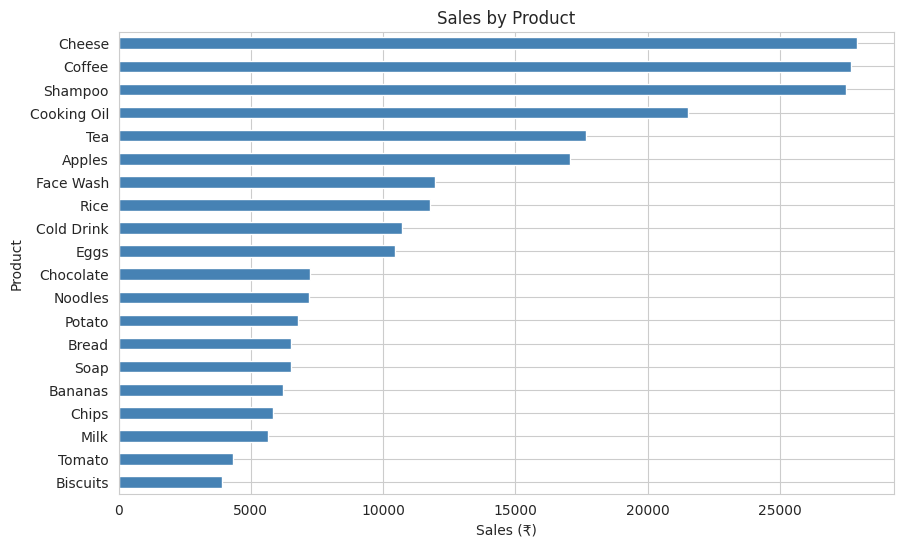

In [54]:

plt.figure(figsize=(10, 6))

product_sales.sort_values().plot(
    kind='barh',
    color='steelblue'
)

plt.title('Sales by Product')
plt.xlabel('Sales (₹)')
plt.ylabel('Product')
plt.show()


**2. Which branch performs best?**

In [44]:
branch_sales = df.groupby('Branch')['Sales'].sum()

best_branch = branch_sales.idxmax()
best_branch_sales = branch_sales.max()

best_branch_city = df[df['Branch'] == best_branch]['City'].iloc[0]

print(
    f"Branch {best_branch} ({best_branch_city}) performed best "
    f"with sales of ₹{best_branch_sales:,.2f}."
)


Branch C (Mumbai) performed best with sales of ₹72,469.45.


Visualization

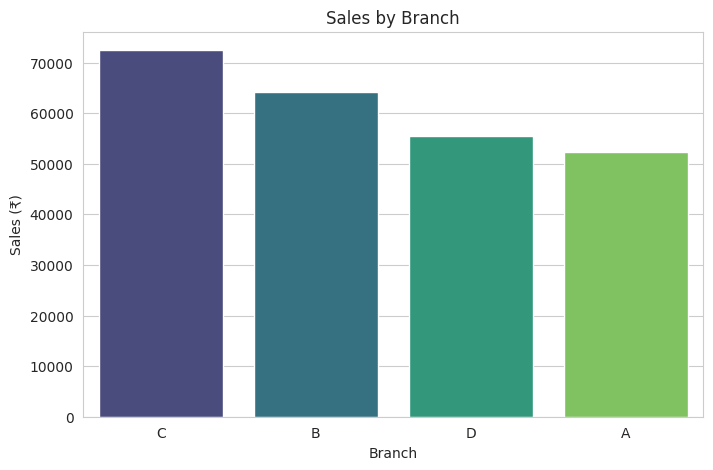

In [57]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=branch_sales.index,
    y=branch_sales.values,
    hue=branch_sales.index,
    palette='viridis',
    legend=False
)

plt.title('Sales by Branch')
plt.xlabel('Branch')
plt.ylabel('Sales (₹)')
plt.show()


 **3. Which category sells the most?**

In [45]:
category_sales = df.groupby('Category')['Sales'].sum()

highest_category = category_sales.idxmax()
highest_category_sales = category_sales.max()

print(
    f"{highest_category} had the highest sales: "
    f"₹{highest_category_sales:,.2f}."
)


Beverages had the highest sales: ₹56,108.24.


Visualization

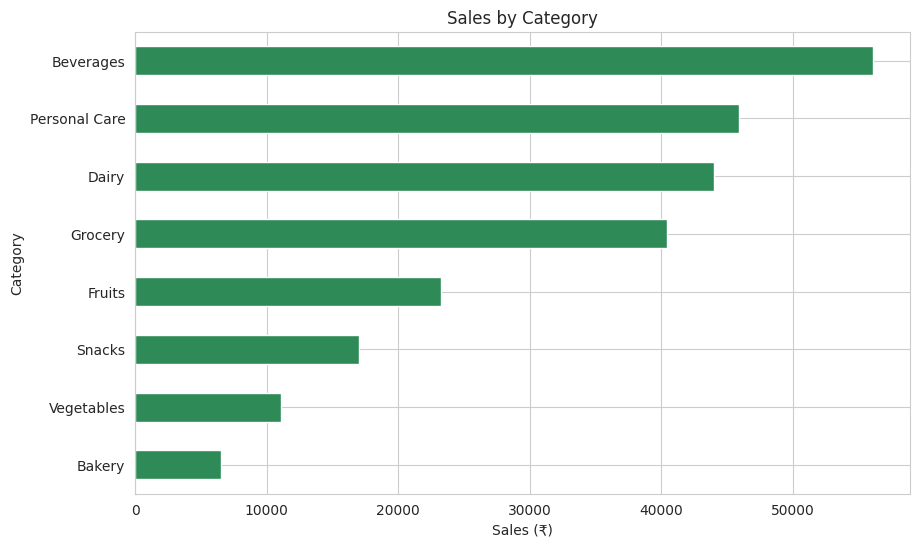

In [58]:
plt.figure(figsize=(10, 6))

category_sales.sort_values().plot(
    kind='barh',
    color='seagreen'
)

plt.title('Sales by Category')
plt.xlabel('Sales (₹)')
plt.ylabel('Category')
plt.show()


**4. What is the most popular payment method?**

In [46]:
payment_counts = df['Payment'].value_counts()

popular_payment = payment_counts.idxmax()
popular_payment_count = payment_counts.max()

print(
    f"{popular_payment} was the most used payment method "
    f"with {popular_payment_count} transactions."
)


UPI was the most used payment method with 127 transactions.


Visualization

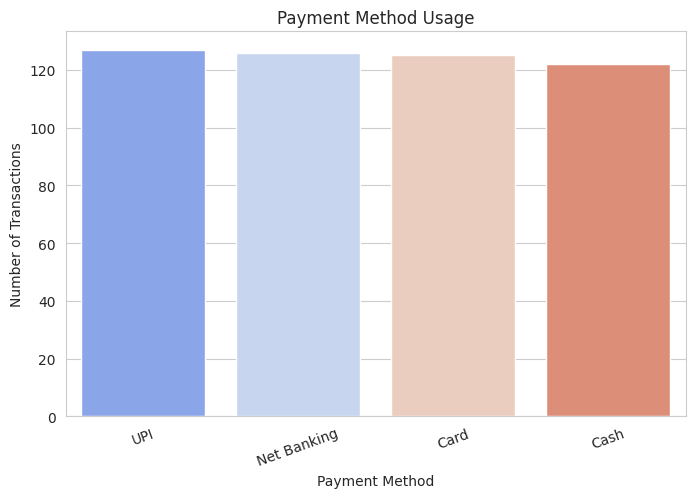

In [59]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values,
    hue=payment_counts.index,
    palette='coolwarm',
    legend=False
)

plt.title('Payment Method Usage')
plt.xlabel('Payment Method')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=20)
plt.show()


**5. Do Members spend more than Normal customers?**

In [47]:
customer_average = df.groupby('Customer Type')['Sales'].mean()

member_average = customer_average['Member']
normal_average = customer_average['Normal']

print(f"Average Member transaction: ₹{member_average:,.2f}")
print(f"Average Normal transaction: ₹{normal_average:,.2f}")

if member_average > normal_average:
    print("Yes. Members have a higher average transaction value.")
else:
    print("No. Normal customers have a higher average transaction value.")


Average Member transaction: ₹483.14
Average Normal transaction: ₹497.07
No. Normal customers have a higher average transaction value.



**6. What is the average customer rating?**

In [48]:
average_rating = df['Rating'].mean()

print(f"The average customer rating was {average_rating:.2f} out of 5.")


The average customer rating was 3.99 out of 5.


Visualization

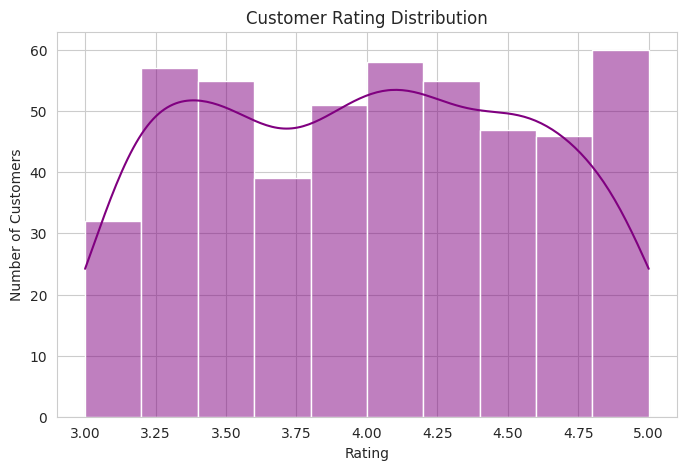

In [61]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df['Rating'],
    bins=10,
    kde=True,
    color='purple'
)

plt.title('Customer Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Customers')
plt.show()


In [49]:
print("========== LIVE ANALYSIS ==========\n")

print(f"1. Highest-selling product: {highest_product}")
print(f"   Sales: ₹{highest_product_sales:,.2f}\n")

print(f"2. Best-performing branch: Branch {best_branch} ({best_branch_city})")
print(f"   Sales: ₹{best_branch_sales:,.2f}\n")

print(f"3. Highest-selling category: {highest_category}")
print(f"   Sales: ₹{highest_category_sales:,.2f}\n")

print(f"4. Most popular payment method: {popular_payment}")
print(f"   Transactions: {popular_payment_count}\n")

print(f"5. Average Member transaction: ₹{member_average:,.2f}")
print(f"   Average Normal transaction: ₹{normal_average:,.2f}")

if member_average > normal_average:
    print("   Members spend more on average.")
else:
    print("   Normal customers spend more on average.")

print(f"\n6. Average customer rating: {average_rating:.2f}/5")


========== LIVE ANALYSIS ==========

1. Highest-selling product: Cheese
   Sales: ₹27,906.30

2. Best-performing branch: Branch C (Mumbai)
   Sales: ₹72,469.45

3. Highest-selling category: Beverages
   Sales: ₹56,108.24

4. Most popular payment method: UPI
   Transactions: 127

5. Average Member transaction: ₹483.14
   Average Normal transaction: ₹497.07
   Normal customers spend more on average.

6. Average customer rating: 3.99/5
